,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [3]:
df.shape

(10800, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

In [6]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(504)

In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [14]:
df['Sales'].describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

In [15]:
df=df.drop_duplicates()
df.shape

(10296, 21)

In [17]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       302
Ship Date        302
Ship Mode        302
Customer ID      302
Customer Name    302
Segment          302
Country          302
City             302
State            302
Postal Code      313
Region           302
Product ID       302
Category         302
Sub-Category     302
Product Name     302
Sales            302
Quantity         302
Discount         302
Profit           302
dtype: int64

In [18]:
df_clean=df.dropna()
df_clean.shape

(9983, 21)

In [19]:
df_cl=df.dropna()
df_cl.shape

(9983, 21)

In [20]:
df_clean.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Matplotlib is building the font cache; this may take a moment.


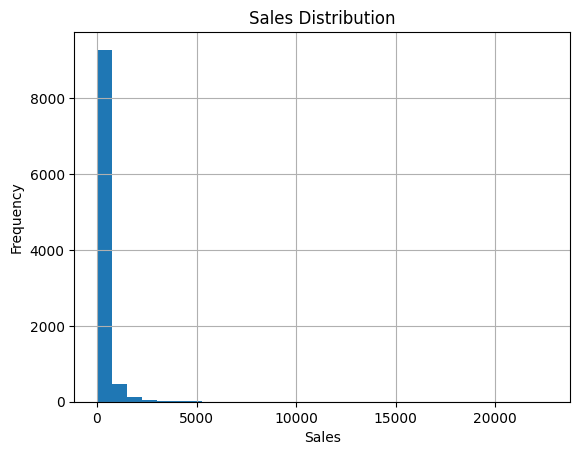

In [23]:
import matplotlib.pyplot as plt
df_clean['Sales'].hist(bins=30)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

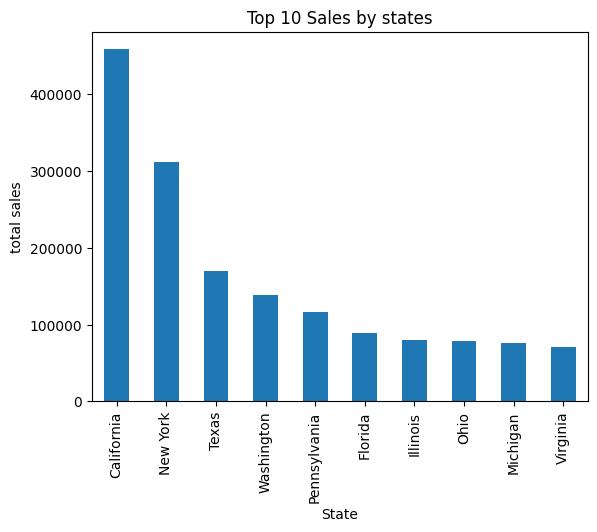

In [26]:
topState=df_clean.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
topState.plot(kind='bar')
plt.title("Top 10 Sales by states")
plt.ylabel("total sales")
plt.show()

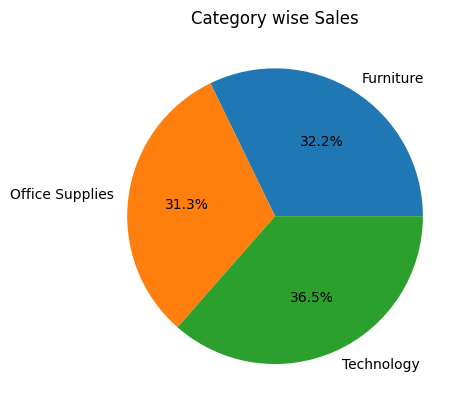

In [29]:
cat_sales=df_clean.groupby('Category')['Sales'].sum()
cat_sales.plot(kind='pie',autopct='%1.1f%%')
plt.title("Category wise Sales")
plt.ylabel("")
plt.show()

In [39]:
df_clean.to_csv("C:/Users/peddi/OneDrive/Documents/Desktop/apexplanet-data-analytics/data/superstore_clean.csv", index=False)

In [40]:
import os
os.listdir("C:/Users/peddi/OneDrive/Documents/Desktop/apexplanet-data-analytics/data")

['superstore.csv', 'superstore_clean.csv']